## Advanced Data Visualisation and Seaborn

### Initialising Libraries

In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches # needed for waffle Charts

In [2]:
mpl.style.use('ggplot') # optional: for ggplot-like style

In [3]:
import numpy as np  
import pandas as pd 

In [4]:
import seaborn as sns
from pywaffle import Waffle
import wordcloud # Needed for word cloud graph
from wordcloud import WordCloud, STOPWORDS
import urllib

### Fetching Data

In [5]:
df_can = pd.read_csv('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DV0101EN-SkillsNetwork/Data%20Files/Canada.csv')

### Data Wrangling

In [6]:
df_can.set_index('Country', inplace=True)

### Waffle Chart

C:\Users\sfauz\AppData\Local\Temp\ipykernel_8740\3845204969.py:61: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  total_values = values_cumsum[len(values_cumsum) - 1]
C:\Users\sfauz\AppData\Local\Temp\ipykernel_8740\3845204969.py:66: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  label_str = category + ' (' + str(df_dsn['Total'][i]) + ')'
C:\Users\sfauz\AppData\Local\Temp\ipykernel_8740\3845204969.py:67: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `s

<Figure size 640x480 with 0 Axes>

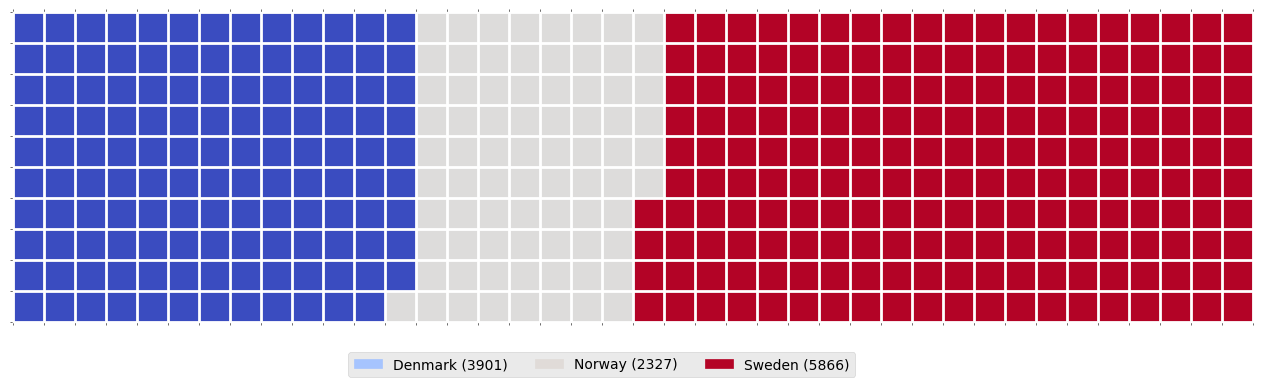

In [7]:
#  Waffle Chart from scratch

df_dsn = df_can.loc[['Denmark', 'Norway', 'Sweden'], :] 

total_value = df_dsn["Total"].sum()
proportions = df_dsn["Total"] / total_value

# Initilise the values of the waffle chart

width = 40
height = 10

total_size = width * height

# Use the proportions to determine the amount of tiles for each country

tiles_in_proportion = (proportions * total_size).round().astype(int)

# Create a matrix the resembles the waffle chart

waffle_chart = np.zeros((height, width), dtype= np.uint )

# define loop variables

country_index = 0
tile_index = 0

# Populate the waffle chart

for col in range(width):
    for row in range(height):
        tile_index += 1

        if tile_index > sum(tiles_in_proportion[0:country_index]):
            country_index += 1
        
        waffle_chart[row, col] = country_index

# Map the matrix into a visual and prettify it.

fig = plt.figure()

colourmap = plt.cm.coolwarm
plt.matshow(waffle_chart, cmap = colourmap)

# get the axis
ax = plt.gca()

# set minor ticks
ax.set_xticks(np.arange(-.5, (width), 1), minor=True)
ax.set_yticks(np.arange(-.5, (height), 1), minor=True)
    
# add gridlines based on minor ticks
ax.grid(which='minor', color='w', linestyle='-', linewidth=2)

plt.xticks([])
plt.yticks([])

# compute cumulative sum of individual categories to match color schemes between chart and legend
values_cumsum = np.cumsum(df_dsn['Total'])
total_values = values_cumsum[len(values_cumsum) - 1]

# create legend
legend_handles = []
for i, category in enumerate(df_dsn.index.values):
    label_str = category + ' (' + str(df_dsn['Total'][i]) + ')'
    color_val = colourmap(float(values_cumsum[i])/total_values)
    legend_handles.append(mpatches.Patch(color=color_val, label=label_str))

# add legend to chart
plt.legend(handles=legend_handles,
           loc='lower center', 
           ncol=len(df_dsn.index.values),
           bbox_to_anchor=(0., -0.2, 0.95, .1)
          )

plt.show()

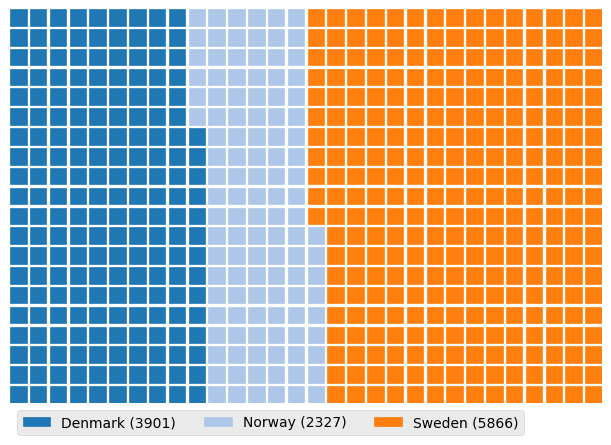

In [8]:
#Set up the Waffle chart figure with the lib

fig = plt.figure(FigureClass = Waffle,
                 rows = 20, columns = 30, #pass the number of rows and columns for the waffle 
                 values = df_dsn['Total'], #pass the data to be used for display
                 cmap_name = 'tab20', #color scheme
                 legend = {'labels': [f"{k} ({v})" for k, v in zip(df_dsn.index.values,df_dsn.Total)],
                            'loc': 'lower left', 'bbox_to_anchor':(0,-0.1),'ncol': 3}
                 #notice the use of list comprehension for creating labels 
                 #from index and total of the dataset
                )

plt.show()

### Word Cloud

In [9]:
# Here we are going to analyse the words from Alice in Wonderland

alice_novel = urllib.request.urlopen('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DV0101EN-SkillsNetwork/Data%20Files/alice_novel.txt').read().decode("utf-8")

In [10]:
stopwords = set(STOPWORDS) # Words to not include i assume

In [11]:
# instantiate a word cloud object
alice_wc = WordCloud()
# generate the word cloud
alice_wc.generate(alice_novel)

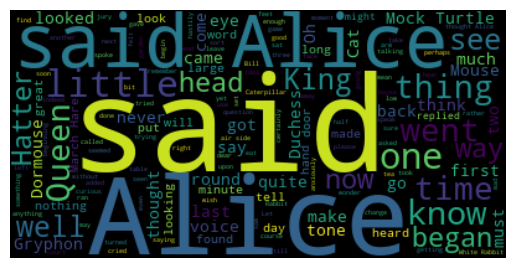

In [12]:
# display the word cloud

plt.imshow(alice_wc, interpolation='bilinear')
plt.axis('off')
plt.show()                                          

### Seaborn

<Axes: xlabel='Continent', ylabel='count'>

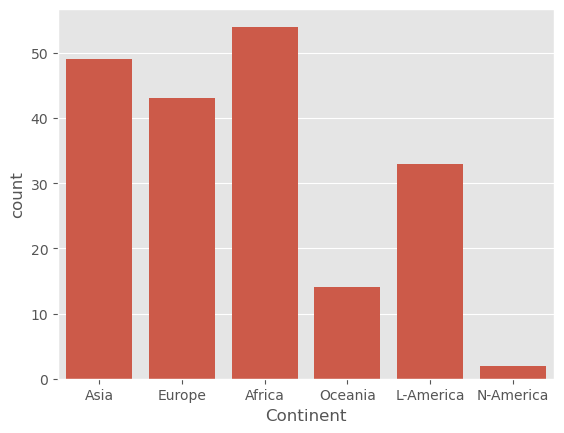

In [13]:
# Count plot
# Had some problem with x-axis labels
df_can1 = df_can.replace('Latin America and the Caribbean', 'L-America')
df_can1 = df_can1.replace('Northern America', 'N-America')
sns.countplot(x='Continent', data=df_can1)

<Axes: xlabel='Continent', ylabel='Total'>

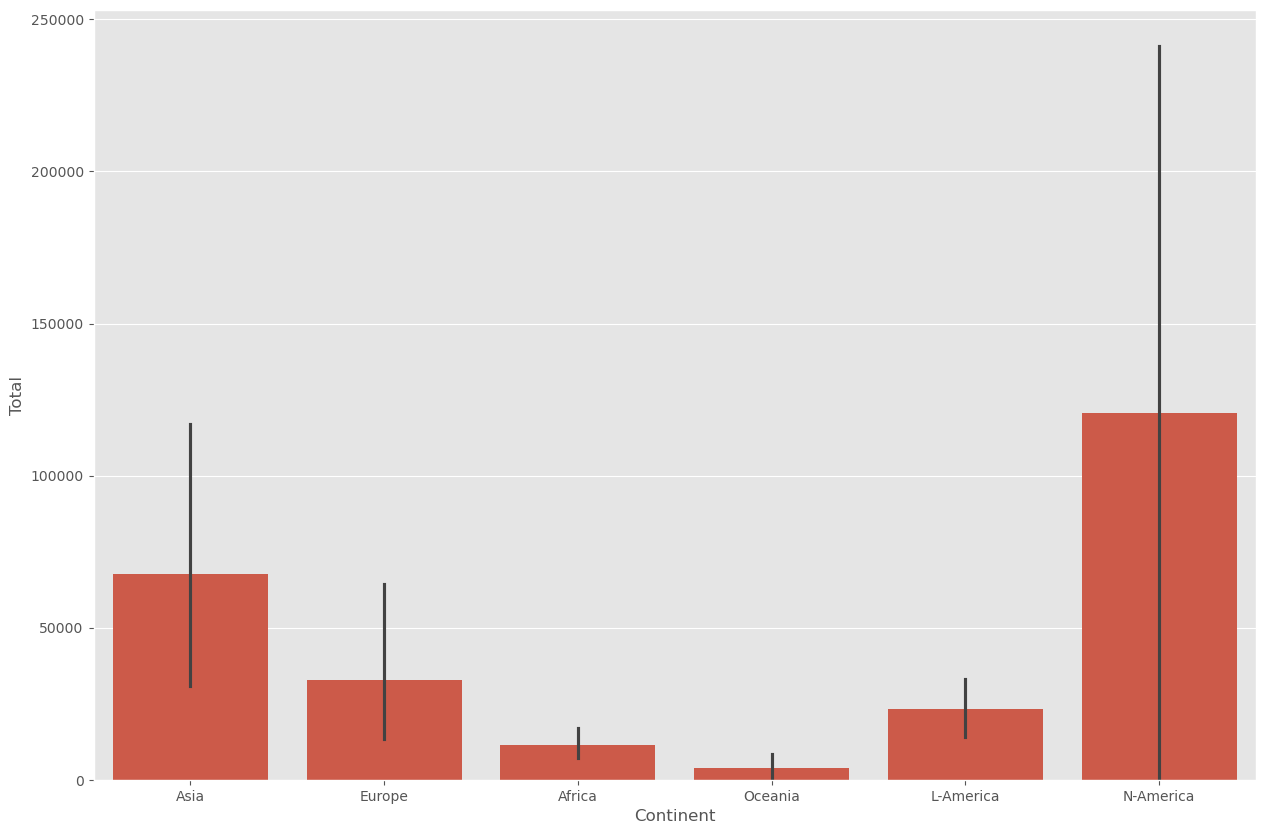

In [14]:
# Bar Plot

plt.figure(figsize=(15, 10))
sns.barplot(x='Continent', y='Total', data=df_can1)

<Axes: xlabel='year', ylabel='total'>

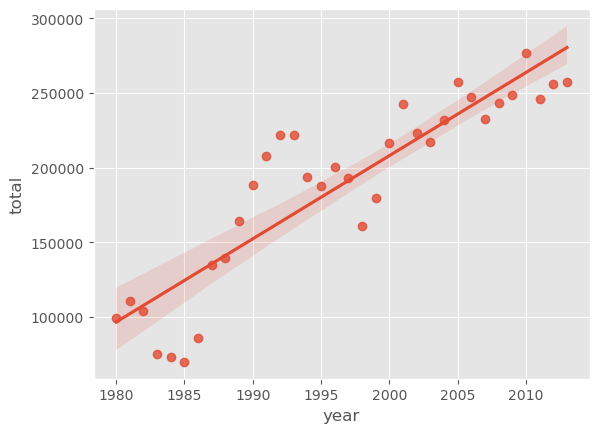

In [15]:
# Regression Plot

years = list(map(str, range(1980, 2014)))
# we can use the sum() method to get the total population per year
df_tot = pd.DataFrame(df_can[years].sum(axis=0))

# change the years to type float (useful for regression later on)
df_tot.index = map(float, df_tot.index)

# reset the index to put in back in as a column in the df_tot dataframe
df_tot.reset_index(inplace=True)

# rename columns
df_tot.columns = ['year', 'total']

# view the final dataframe
df_tot.head()

sns.regplot(x='year', y='total', data=df_tot)

### Folium

In [16]:
import folium

In [17]:
m = folium.Map(location=(7.8, 80.770298), zoom_start=8, tiles='Cartodb positron')
m
m.save("index.html")

In [18]:
# Lets apply this

df_incidents = pd.read_csv('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DV0101EN-SkillsNetwork/Data%20Files/Police_Department_Incidents_-_Previous_Year__2016_.csv')

In [19]:
# get the first 100 crimes in the df_incidents dataframe
df_incidents = df_incidents.iloc[0:100, :]

In [20]:
# San Francisco latitude and longitude values
latitude = 37.77
longitude = -122.42

In [21]:
# Geospactial Map
# Clustering makes it so when you zoom out the markers become one
from folium import plugins

sanfran_map = folium.Map(location=[latitude, longitude], zoom_start=12)

incidents = plugins.MarkerCluster().add_to(sanfran_map)

for lat, lng, label, in zip(df_incidents.Y, df_incidents.X, df_incidents.Category):
    folium.Marker(
        location=[lat, lng],
        icon=None,
        popup=label,
    ).add_to(incidents)

# add pop-up text to each marker on the map
latitudes = list(df_incidents.Y)
longitudes = list(df_incidents.X)
labels = list(df_incidents.Category)

for lat, lng, label in zip(latitudes, longitudes, labels):
    folium.Marker([lat, lng], popup=label).add_to(sanfran_map)    

sanfran_map.add_child(incidents)

sanfran_map.save("crime.html")

In [26]:
# Choropleth Map

df_can = pd.read_csv('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DV0101EN-SkillsNetwork/Data%20Files/Canada.csv')

world_geo = r'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DV0101EN-SkillsNetwork/Data%20Files/world_countries.json'

world_map = folium.Map(location=[0, 0], zoom_start=2)

folium.Choropleth(
    geo_data=world_geo,
    data=df_can,
    columns=['Country', 'Total'],
    key_on='feature.properties.name',
    fill_color='YlOrRd', 
    fill_opacity=0.7, 
    line_opacity=0.2,
    legend_name='Immigration to Canada',
    reset=True
).add_to(world_map)

world_map.save("world.html")